#**Machine Learning-Based Revenue Forecasting** and Onboarding Patterns Across Multi-Country Payment Networks: **A Case Study of Arab Financial Services**

#**UAE AFS (Arab Financial Services) Forcast Revenue**

#SECTION 1 — Setup: Google Drive + Libraries

In [1]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Core libraries ---
import pandas as pd
import numpy as np

# --- Feature Engineering ---
!pip install holidays -q
import holidays
!pip install hijridate -q
from hijridate import Gregorian

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# --- Modelling ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
!pip install lightgbm catboost pmdarima -q
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# --- Display settings ---
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# --- File path ---
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Thesis/Thesis_Datasets/UAE_AFS_daily_revenue_dataset_v3.xlsx'

print('Setup complete.')
print('Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 53.0 MB/s eta 0:00:00
Setup complete.
Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost


#SECTION 2 — Data Structure

In [2]:
df_raw = pd.read_excel(FILE_PATH)
df_raw['Settlement Date'] = pd.to_datetime(df_raw['Settlement Date'])

# ---------- 2.1 Structure ----------
print('=' * 70)
print('2.1  DATA STRUCTURE')
print('=' * 70)
print(f'Shape       : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns')
print(f'Date range  : {df_raw["Settlement Date"].min().date()}  ->  {df_raw["Settlement Date"].max().date()}')
print(f'Memory      : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB')
print()
print(df_raw.dtypes.to_frame('dtype').to_string())
print()
display(df_raw.head())

# ---------- 2.2 Data quality: nulls, duplicates, zeros ----------
print('=' * 70)
print('2.2  DATA QUALITY')
print('=' * 70)

quality = pd.DataFrame({
    'dtype'  : df_raw.dtypes.astype(str),
    'nulls'  : df_raw.isna().sum(),
    'null_%' : (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'zeros'  : (df_raw == 0).sum(),
    'unique' : df_raw.nunique(),
})
display(quality)

print(f'Duplicate full rows       : {df_raw.duplicated().sum()}')
print(f'Duplicate Settlement Dates: {df_raw["Settlement Date"].duplicated().sum()}')

full_range   = pd.date_range(df_raw['Settlement Date'].min(),
                             df_raw['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df_raw['Settlement Date'])
print(f'Missing calendar days     : {len(missing_days)}')
if 0 < len(missing_days) <= 10:
    print(f'   -> {list(missing_days.date)}')
print()

# ---------- 2.3 Statistical summary ----------
print('=' * 70)
print('2.3  STATISTICAL SUMMARY')
print('=' * 70)
num_cols = ['Transaction Count', 'Transaction Amount',
            'Average Transaction Amount', 'Profit']
stats = df_raw[num_cols].describe().T
stats['skew'] = df_raw[num_cols].skew()
display(stats.round(2))

# ---------- 2.4 Yearly consistency (margin check) ----------
print('=' * 70)
print('2.4  YEARLY BREAKDOWN — margin consistency check')
print('=' * 70)
yr = df_raw.groupby(df_raw['Settlement Date'].dt.year).agg(
    days             = ('Profit', 'size'),
    txn_count        = ('Transaction Count', 'sum'),
    amount           = ('Transaction Amount', 'sum'),
    profit           = ('Profit', 'sum'),
    avg_daily_profit = ('Profit', 'mean'),
)
yr['margin_%'] = (yr['profit'] / yr['amount'] * 100).round(2)
display(yr.round(0))

2.1  DATA STRUCTURE
Shape       : 551 rows  x  15 columns
Date range  : 2025-01-09  ->  2026-07-14
Memory      : 139.0 KB

                                     dtype
Country                             object
Source                              object
Currency                            object
Transaction Count                    int64
Transaction Amount                 float64
Average Transaction Amount         float64
Profit                             float64
Settlement Year                      int64
Settlement Month                     int64
Settlement Date             datetime64[ns]
Settlement Day                       int64
is_weekend                           int64
is_holiday                           int64
is_ramadan                           int64
ramadan_last10                       int64



,Country,Source,Currency,Transaction Count,Transaction Amount,Average Transaction Amount,Profit,Settlement Year,Settlement Month,Settlement Date,Settlement Day,is_weekend,is_holiday,is_ramadan,ramadan_last10
0,UAE,NewCMMUAE,AED,107,"3,003,456.83","28,069.69","35,440.79",2025,1,2025-01-09,3,0,0,0,0
1,UAE,NewCMMUAE,AED,97,"2,744,429.73","28,293.09","32,913.29",2025,1,2025-01-10,4,0,0,0,0
2,UAE,NewCMMUAE,AED,77,"2,167,723.25","28,152.25","25,895.10",2025,1,2025-01-11,5,1,0,0,0
3,UAE,NewCMMUAE,AED,75,"2,104,113.00","28,054.84","24,678.97",2025,1,2025-01-12,6,1,0,0,0
4,UAE,NewCMMUAE,AED,118,"3,338,997.62","28,296.59","39,523.32",2025,1,2025-01-13,0,0,0,0,0


2.2  DATA QUALITY


,dtype,nulls,null_%,zeros,unique
Country,object,0,0.00,0,1
Source,object,0,0.00,0,1
Currency,object,0,0.00,0,1
Transaction Count,int64,0,0.00,0,518
Transaction Amount,float64,0,0.00,0,551
Average Transaction Amount,float64,0,0.00,0,551
Profit,float64,0,0.00,0,551
Settlement Year,int64,0,0.00,0,2
Settlement Month,int64,0,0.00,0,12
Settlement Date,datetime64[ns],0,0.00,0,551


Duplicate full rows       : 0
Duplicate Settlement Dates: 0
Missing calendar days     : 1
   -> [datetime.date(2026, 6, 25)]

2.3  STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max,skew
Transaction Count,551.00,"4,085.66","2,811.92",75.00,"1,030.50","4,535.00","6,756.50","9,645.00",-0.06
Transaction Amount,551.00,"472,443,609.39","404,405,054.47","2,104,113.00","42,776,933.94","435,682,372.51","824,786,737.48","1,332,258,464.80",0.29
Average Transaction Amount,551.00,"88,457.73","42,889.85","27,492.21","43,657.26","90,489.80","132,389.67","152,197.36",-0.07
Profit,551.00,"5,631,930.26","4,860,674.72","24,678.97","514,544.15","5,162,589.88","9,697,623.20","16,716,441.46",0.33


2.4  YEARLY BREAKDOWN — margin consistency check


,days,txn_count,amount,profit,avg_daily_profit,margin_%
Settlement Date,,,,,,
2025,357,949419,"82,775,784,671.00","986,537,485.00","2,763,410.00",1.00
2026,194,1301779,"177,540,644,105.00","2,116,656,088.00","10,910,598.00",1.00


#SECTION 3 — Cleaning

In [3]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

# ---------- 3.1 Drop constant metadata columns ----------
df = df.drop(columns=['Country', 'Source', 'Currency'], errors='ignore')

# ---------- 3.2 Resolve duplicate dates (sum the additive metrics) ----------
n_dups = df['Settlement Date'].duplicated().sum()
df = (df.groupby('Settlement Date', as_index=False)
        .agg({'Transaction Count' : 'sum',
              'Transaction Amount': 'sum',
              'Profit'            : 'sum'}))

# ---------- 3.3 Fill missing calendar days with that MONTH's average ----------
df = df.sort_values('Settlement Date').reset_index(drop=True)

full_range   = pd.date_range(df['Settlement Date'].min(),
                             df['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df['Settlement Date'])

if len(missing_days) > 0:
    df['_ym']  = df['Settlement Date'].dt.to_period('M')
    month_avg  = df.groupby('_ym')[['Transaction Count',
                                    'Transaction Amount',
                                    'Profit']].mean()

    fills = []
    for d in missing_days:
        ym   = pd.Period(d, freq='M')
        vals = month_avg.loc[ym] if ym in month_avg.index else \
               df[['Transaction Count','Transaction Amount','Profit']].mean()
        fills.append({'Settlement Date'   : d,
                      'Transaction Count' : vals['Transaction Count'],
                      'Transaction Amount': vals['Transaction Amount'],
                      'Profit'            : vals['Profit']})

    df = df.drop(columns='_ym')
    df = pd.concat([df, pd.DataFrame(fills)], ignore_index=True)
    df = df.sort_values('Settlement Date').reset_index(drop=True)

# ---------- 3.4 Recompute Average Transaction Amount ----------
df['Average Transaction Amount'] = (
    df['Transaction Amount'] / df['Transaction Count']
).replace([np.inf, -np.inf], np.nan)

# ---------- 3.5 Rebuild calendar columns ----------
df['Settlement Year']  = df['Settlement Date'].dt.year
df['Settlement Month'] = df['Settlement Date'].dt.month
df['Settlement Day']   = df['Settlement Date'].dt.dayofweek   # 0=Mon ... 6=Sun

# ---------- 3.6 Verification ----------
final_range   = pd.date_range(df['Settlement Date'].min(),
                              df['Settlement Date'].max(), freq='D')
still_missing = final_range.difference(df['Settlement Date'])

print('=' * 70)
print('CLEANING VERIFICATION')
print('=' * 70)
print(f'Rows            : {len(df_raw):,}  ->  {len(df):,}')
print(f'Duplicate dates : {n_dups}  ->  {df["Settlement Date"].duplicated().sum()}')
print(f'Missing days    : {len(missing_days)}  ->  {len(still_missing)} ')
if len(missing_days):
    print(f'   filled       : {list(missing_days.date)}')
print(f'Profit zeros    : {(df["Profit"] == 0).sum()}')
print(f'Nulls remaining : {df.isna().sum().sum()}')
print()
print(f'Avg Txn Amount  : min {df["Average Transaction Amount"].min():.2f}  '
      f'max {df["Average Transaction Amount"].max():.2f}  '
      f'median {df["Average Transaction Amount"].median():.2f}')
print(f'Columns: {list(df.columns)}')
display(df.head())

CLEANING VERIFICATION
Rows            : 551  ->  552
Duplicate dates : 0  ->  0
Missing days    : 1  ->  0 
   filled       : [datetime.date(2026, 6, 25)]
Profit zeros    : 0
Nulls remaining : 0

Avg Txn Amount  : min 27492.21  max 152197.36  median 90640.23
Columns: ['Settlement Date', 'Transaction Count', 'Transaction Amount', 'Profit', 'Average Transaction Amount', 'Settlement Year', 'Settlement Month', 'Settlement Day']


,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day
0,2025-01-09,107.00,"3,003,456.83","35,440.79","28,069.69",2025,1,3
1,2025-01-10,97.00,"2,744,429.73","32,913.29","28,293.09",2025,1,4
2,2025-01-11,77.00,"2,167,723.25","25,895.10","28,152.25",2025,1,5
3,2025-01-12,75.00,"2,104,113.00","24,678.97","28,054.84",2025,1,6
4,2025-01-13,118.00,"3,338,997.62","39,523.32","28,296.59",2025,1,0


#SECTION 5 — Feature Engineering

In [4]:
# ---------- 5.1 is_weekend (UAE: Saturday=5, Sunday=6) ----------
df['is_weekend'] = df['Settlement Date'].dt.dayofweek.isin([6, 5]).astype(int)

# ---------- 5.2 is_holiday (UAE public holidays) ----------
UAE_holidays = holidays.UnitedArabEmirates(years=[2025, 2026])
df['is_holiday'] = df['Settlement Date'].dt.date.isin(UAE_holidays).astype(int)
print(f'Holiday days flagged: {df["is_holiday"].sum()}')

# ---------- 5.3 Lag & rolling features ----------
df['lag_1']           = df['Profit'].shift(1)                        # yesterday's profit
df['avg_tran_lag1'] = df['Average Transaction Amount'].shift(1)    # yesterday's avg ticket size
df['roll7_mean']      = df['Profit'].rolling(7).mean().shift(1)      # last 7-day avg profit
df['lag_28']          = df['Profit'].shift(28)                       # four weeks back (monthly cycle)

# ---------- 5.4 Islamic-calendar (Hijri) features ----------
# Ramadan spending drops ~26.5%; it shifts ~11 days earlier each Gregorian year,
# so Settlement Month cannot capture it — a Hijri flag is required.
def _hijri(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return pd.Series({'hijri_month': h.month, 'hijri_day': h.day})

_h = df['Settlement Date'].apply(_hijri)
df['hijri_month'] = _h['hijri_month']
df['hijri_day']   = _h['hijri_day']

df['is_ramadan']     = (df['hijri_month'] == 9).astype(int)                        # month 9 = Ramadan
df['ramadan_last10'] = ((df['hijri_month'] == 9) & (df['hijri_day'] >= 20)).astype(int)  # pre-Eid peak

print(f'Ramadan days flagged   : {df["is_ramadan"].sum()}')

# drop the raw hijri_month/day — they HURT as ordinal features (cyclical); keep only the flags
df = df.drop(columns=['hijri_month', 'hijri_day'])

# ---------- 5.5 FINAL DATASET ----------
print('=' * 70)
print('FINAL DATASET')
print('=' * 70)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print()
print('--- First 10 rows ---')
display(df.head(10))

# ---------- 5.6 Ramadan effect check (nice for the thesis) ----------
print('\nRamadan effect on profit:')
r = df[df['is_ramadan']==1]['Profit'].mean()
n = df[df['is_ramadan']==0]['Profit'].mean()
print(f'  Ramadan    : {r:,.0f} AED/day')
print(f'  Non-Ramadan: {n:,.0f} AED/day')
print(f'  Effect     : {(r/n-1)*100:+.1f}%')

Holiday days flagged: 20
Ramadan days flagged   : 59
FINAL DATASET
Shape: 552 rows x 16 columns
Columns: ['Settlement Date', 'Transaction Count', 'Transaction Amount', 'Profit', 'Average Transaction Amount', 'Settlement Year', 'Settlement Month', 'Settlement Day', 'is_weekend', 'is_holiday', 'lag_1', 'avg_tran_lag1', 'roll7_mean', 'lag_28', 'is_ramadan', 'ramadan_last10']

--- First 10 rows ---


,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day,is_weekend,is_holiday,lag_1,avg_tran_lag1,roll7_mean,lag_28,is_ramadan,ramadan_last10
0,2025-01-09,107.00,"3,003,456.83","35,440.79","28,069.69",2025,1,3,0,0,NaN,NaN,NaN,NaN,0,0
1,2025-01-10,97.00,"2,744,429.73","32,913.29","28,293.09",2025,1,4,0,0,"35,440.79","28,069.69",NaN,NaN,0,0
2,2025-01-11,77.00,"2,167,723.25","25,895.10","28,152.25",2025,1,5,1,0,"32,913.29","28,293.09",NaN,NaN,0,0
3,2025-01-12,75.00,"2,104,113.00","24,678.97","28,054.84",2025,1,6,1,0,"25,895.10","28,152.25",NaN,NaN,0,0
4,2025-01-13,118.00,"3,338,997.62","39,523.32","28,296.59",2025,1,0,0,0,"24,678.97","28,054.84",NaN,NaN,0,0
5,2025-01-14,116.00,"3,386,202.40","39,961.79","29,191.40",2025,1,1,0,0,"39,523.32","28,296.59",NaN,NaN,0,0
6,2025-01-15,116.00,"3,254,044.76","38,803.92","28,052.11",2025,1,2,0,0,"39,961.79","29,191.40",NaN,NaN,0,0
7,2025-01-16,126.00,"3,464,018.46","40,823.05","27,492.21",2025,1,3,0,0,"38,803.92","28,052.11","33,888.17",NaN,0,0
8,2025-01-17,110.00,"3,174,200.70","37,940.61","28,856.37",2025,1,4,0,0,"40,823.05","27,492.21","34,657.06",NaN,0,0
9,2025-01-18,87.00,"2,485,420.35","29,199.44","28,568.05",2025,1,5,1,0,"37,940.61","28,856.37","35,375.25",NaN,0,0



Ramadan effect on profit:
  Ramadan    : 5,459,658 AED/day
  Non-Ramadan: 5,665,513 AED/day
  Effect     : -3.6%


#SECTION 7: Model Training & Evaluation

In [5]:
FEATURES = ['Settlement Year', 'Settlement Month', 'Settlement Day',
            'is_weekend', 'is_holiday',
            'lag_1','avg_tran_lag1','roll7_mean', 'lag_28','is_ramadan', 'ramadan_last10']
TARGET = 'Profit'
SPLIT  = '2026-04-01'

def evaluate(y, p):
    ape = np.abs((y - p) / y) * 100
    return {'MAPE%' : ape.mean(),
            'MAE'   : mean_absolute_error(y, p),
            'RMSE'  : np.sqrt(mean_squared_error(y, p))#,
            #'R2'    : r2_score(y, p)
        }
# ---------- split (once — FEATURES is a single list) ----------
d  = df.dropna(subset=FEATURES + [TARGET]).copy()
tr = d[d['Settlement Date'] <  SPLIT]
te = d[d['Settlement Date'] >= SPLIT]

X_tr, y_tr = tr[FEATURES], tr[TARGET]
X_te, y_te = te[FEATURES], te[TARGET]

print(f'TRAIN: {len(tr):,} rows | {tr["Settlement Date"].min().date()} -> {tr["Settlement Date"].max().date()}')
print(f'TEST : {len(te):,} rows | {te["Settlement Date"].min().date()} -> {te["Settlement Date"].max().date()}')
print()

# ---------- BASELINE ----------
baselines = {
    'Linear Regression': LinearRegression(),
}

# ---------- PROPOSED MODELS ----------
models = {
    'Random Forest'     : RandomForestRegressor(n_estimators=1000,
                                                random_state=42, n_jobs=-1),

    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01,
                                                    max_depth=6, subsample=0.8,
                                                    random_state=42),

    'XGBoost'           : xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01,
                                           max_depth=6, random_state=42, n_jobs=-1),

}

rows = []

for mname, model in baselines.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rows.append({'Type': 'Baseline', 'Model': mname, **evaluate(y_te.values, pred)})

for mname, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rows.append({'Type': 'Proposed', 'Model': mname, **evaluate(y_te.values, pred)})

results = pd.DataFrame(rows)

print('UAE Arab Financial Services (AFS) MODEL COMPARISON (2026 test set)')
display(results.round(2))

TRAIN: 419 rows | 2025-02-06 -> 2026-03-31
TEST : 105 rows | 2026-04-01 -> 2026-07-14

UAE Arab Financial Services (AFS) MODEL COMPARISON (2026 test set)


,Type,Model,MAPE%,MAE,RMSE
0,Baseline,Linear Regression,11.51,"1,179,037.68","1,514,681.27"
1,Proposed,Random Forest,14.04,"1,359,078.55","1,918,337.96"
2,Proposed,Gradient Boosting,12.93,"1,262,268.75","1,755,682.19"
3,Proposed,XGBoost,11.70,"1,185,003.65","1,563,028.79"


#Check Overfitting/Underfitting

In [6]:
def mape(y, p):
    return np.mean(np.abs((y - p) / y)) * 100

# ---- collect train vs test scores for each model ----
names, tr_mape, te_mape, tr_rmse, te_rmse = [], [], [], [], []

for mname, model in {**baselines, **models}.items():
    model.fit(X_tr, y_tr)
    names.append(mname)
    tr_mape.append(mape(y_tr.values, model.predict(X_tr)))
    te_mape.append(mape(y_te.values, model.predict(X_te)))
    tr_rmse.append(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))
    te_rmse.append(np.sqrt(mean_squared_error(y_te, model.predict(X_te))))

# ---- print the gap table ----
print(f'{"Model":<20}{"Train MAPE":>11}{"Test MAPE":>11}{"Gap":>8}')
print('-' * 50)
for i in range(len(names)):
    print(f'{names[i]:<20}{tr_mape[i]:>10.2f}%{te_mape[i]:>10.2f}%{te_mape[i]-tr_mape[i]:>7.1f}')

Model                Train MAPE  Test MAPE     Gap
--------------------------------------------------
Linear Regression       110.72%     11.51%  -99.2
Random Forest             4.07%     14.04%   10.0
Gradient Boosting         2.08%     12.93%   10.8
XGBoost                   3.22%     11.70%    8.5


#SECTION 7: Prediction (Remaining of 2026)

In [ ]:
# ============================================================
# RECURSIVE FORECAST — from end of data to 31 Dec 2026
# ============================================================
FEATURES = ['Settlement Year','Settlement Month','Settlement Day',
            'is_weekend','is_holiday',
            'lag_1','avg_tran_lag1','roll7_mean','lag_28',
            'is_ramadan','ramadan_last10']

UAE = holidays.UnitedArabEmirates(years=[2025,2026])

def hijri_md(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return h.month, h.day

last_date    = df['Settlement Date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), '2026-12-31', freq='D')

profit_hist = list(df['Profit'].values)
# yesterday's avg transaction amount — held at the recent 28-day average across the horizon
avg_tran    = df['Average Transaction Amount'].tail(28).mean()

future_rows = []
for dt in future_dates:
    hm, hd = hijri_md(dt)
    feat = {
        'Settlement Year' : dt.year,
        'Settlement Month': dt.month,
        'Settlement Day'  : dt.dayofweek,
        'is_weekend'      : int(dt.dayofweek in [4, 5]),
        'is_holiday'      : int(dt.date() in UAE),
        'lag_1'           : profit_hist[-1],
        'avg_tran_lag1'   : avg_tran,              # ← matches your column name
        'roll7_mean'      : np.mean(profit_hist[-7:]),
        'lag_28'          : profit_hist[-28],
        'is_ramadan'      : int(hm == 9),
        'ramadan_last10'  : int(hm == 9 and hd >= 20),
    }
    yhat = float(model.predict(pd.DataFrame([feat])[FEATURES])[0])
    profit_hist.append(yhat)
    future_rows.append({'Settlement Date': dt, 'Predicted': yhat})

future = pd.DataFrame(future_rows)

print(f'Forecast: {future["Settlement Date"].min().date()} -> {future["Settlement Date"].max().date()}')
print(f'Days forecast     : {len(future)}')
print(f'Jul-Dec 2026 total: {future["Predicted"].sum():,.0f} AED')
print(f'Daily mean        : {future["Predicted"].mean():,.0f} AED')

# ---- combined table: actuals + forecast ----
actual = df[['Settlement Date','Profit']].rename(columns={'Profit':'Actual'})
actual['Predicted'] = np.nan
actual['Type']      = 'Actual'

fc = future.copy()
fc['Actual'] = np.nan
fc['Type']   = 'Forecast'

combined = pd.concat([actual[['Settlement Date','Actual','Predicted','Type']],
                      fc[['Settlement Date','Actual','Predicted','Type']]],
                     ignore_index=True).sort_values('Settlement Date').reset_index(drop=True)

combined['Profit_Best']       = combined['Actual'].fillna(combined['Predicted'])
combined['Cumulative Profit'] = combined.groupby(combined['Settlement Date'].dt.year)['Profit_Best'].cumsum()

combined.to_csv('UAE_AFS_forecast_2026.csv', index=False)

Forecast: 2026-07-15 -> 2026-12-31
Days forecast     : 170
Jul-Dec 2026 total: 2,120,463,901 AED
Daily mean        : 12,473,317 AED


#Visualization

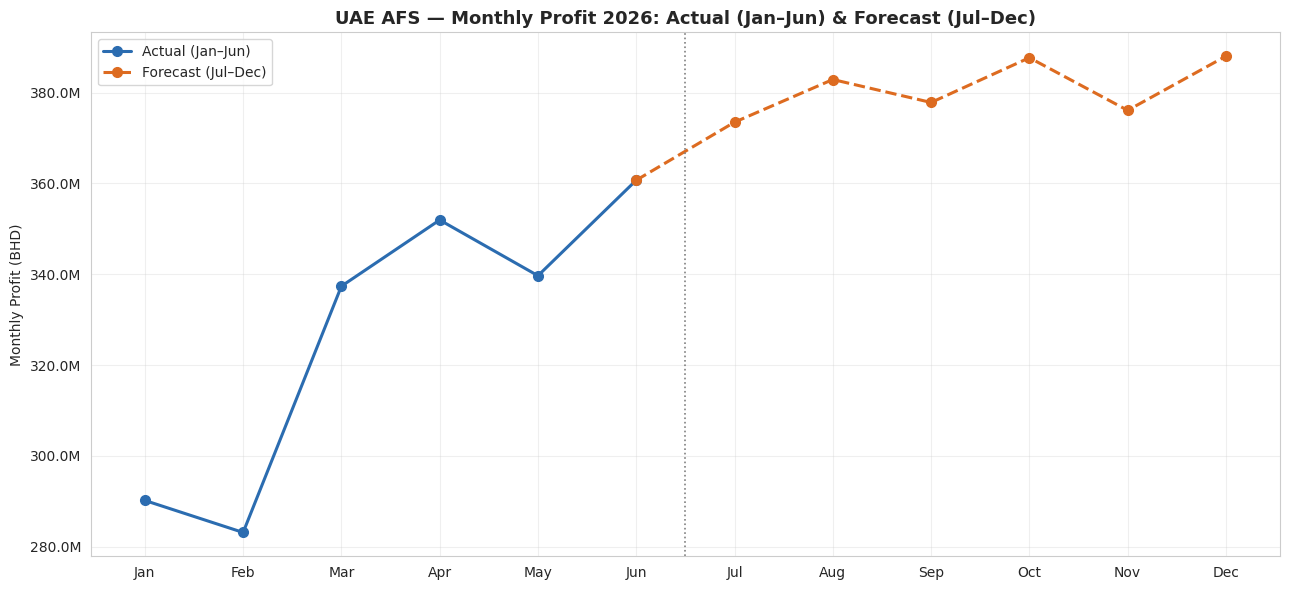

MONTHLY 2026 (AED):
  Jan:  290,210,013  [Actual]
  Feb:  283,162,704  [Actual]
  Mar:  337,381,681  [Actual]
  Apr:  351,959,124  [Actual]
  May:  339,690,528  [Actual]
  Jun:  360,718,303  [Actual]
  Jul:  373,489,865  [Forecast]
  Aug:  382,887,929  [Forecast]
  Sep:  377,830,650  [Forecast]
  Oct:  387,684,859  [Forecast]
  Nov:  376,097,611  [Forecast]
  Dec:  388,030,664  [Forecast]

Total 2026: 4,249,143,932 AED


In [ ]:
# ---- combine 2026 daily actual + forecast, aggregate to MONTHLY ----
a = df[df['Settlement Date'].dt.year == 2026][['Settlement Date','Profit']].rename(columns={'Profit':'val'})
f = future.rename(columns={'Predicted':'val'})[['Settlement Date','val']]

alld = pd.concat([a, f], ignore_index=True).sort_values('Settlement Date')
alld['month'] = alld['Settlement Date'].dt.month
monthly = alld.groupby('month')['val'].sum()

names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
vals  = monthly.reindex(range(1,13)).values

# split: Jan-Jun actual, Jul-Dec forecast (overlap at Jun so the lines connect)
act_x, act_y = list(range(6)),   vals[:6]
fc_x,  fc_y  = list(range(5,12)), vals[5:]

plt.figure(figsize=(13,6))
plt.plot(act_x, act_y, 'o-',  color='#2B6CB0', lw=2.2, markersize=7, label='Actual (Jan–Jun)')
plt.plot(fc_x,  fc_y,  'o--', color='#DD6B20', lw=2.2, markersize=7, label='Forecast (Jul–Dec)')
plt.axvline(5.5, color='gray', ls=':', lw=1.2)

plt.xticks(range(12), names)
plt.ylabel('Monthly Profit (BHD)')
plt.title('UAE AFS — Monthly Profit 2026: Actual (Jan–Jun) & Forecast (Jul–Dec)',
          weight='bold', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# ---- print the monthly table ----
print('MONTHLY 2026 (AED):')
for i, v in enumerate(vals):
    kind = 'Actual' if i < 6 else 'Forecast'
    print(f'  {names[i]}: {v:>12,.0f}  [{kind}]')
print(f'\nTotal 2026: {vals.sum():,.0f} AED')